### 3a. Load and Examine Data

In [2]:
import pandas as pd
import sqlite3

# Load the SQLite database file into a pandas DataFrame
with sqlite3.connect("/Users/luischan/Downloads/hw0-population.db") as db:
    data = pd.read_sql_query("SELECT * FROM population", db)

# Print the columns and the number of rows
print("Columns present in the dataset:", data.columns.tolist())
print("Number of rows (individuals) in the dataset:", len(data))

Columns present in the dataset: ['name', 'age', 'weight', 'eyecolor']
Number of rows (individuals) in the dataset: 152361


### 3b. Analyze Age Distribution

Age - Mean: 39.51052792739697, Std Dev: 24.152760068601573, Min: 0.0007476719217636152, Max: 99.99154733076972


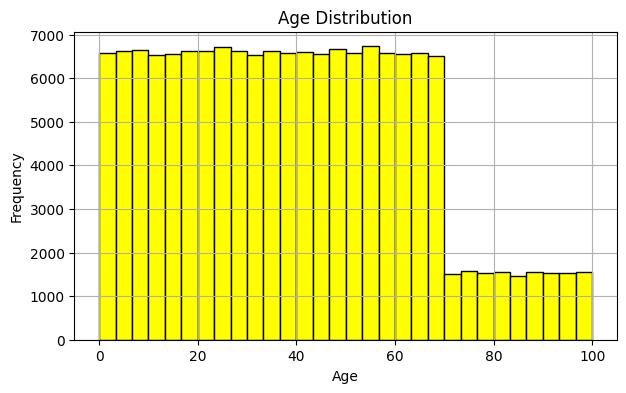

In [6]:
# Compute statistics for the age column
age_mean = data['age'].mean()
age_std = data['age'].std()
age_min = data['age'].min()
age_max = data['age'].max()

print(f"Age - Mean: {age_mean}, Std Dev: {age_std}, Min: {age_min}, Max: {age_max}")

# Plot a histogram of the age distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(data['age'], bins=30, color='yellow', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


### 3c. Analyze Weight Distribution

Weight - Mean: 60.884134159929715, Std Dev: 18.41182426565962, Min: 3.3820836824389326, Max: 100.43579300336947


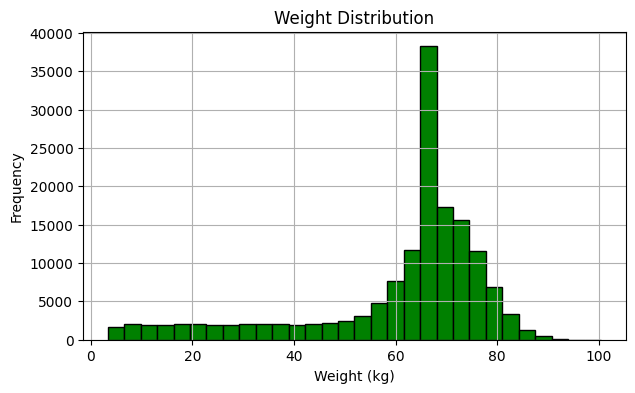

In [8]:
# Compute statistics for the weight column
weight_mean = data['weight'].mean()
weight_std = data['weight'].std()
weight_min = data['weight'].min()
weight_max = data['weight'].max()

print(f"Weight - Mean: {weight_mean}, Std Dev: {weight_std}, Min: {weight_min}, Max: {weight_max}")

# Plot a histogram of the weight distribution
plt.figure(figsize=(7, 4))
plt.hist(data['weight'], bins=30, color='green', edgecolor='black')
plt.title('Weight Distribution')
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


### 3d. Explore Relationships

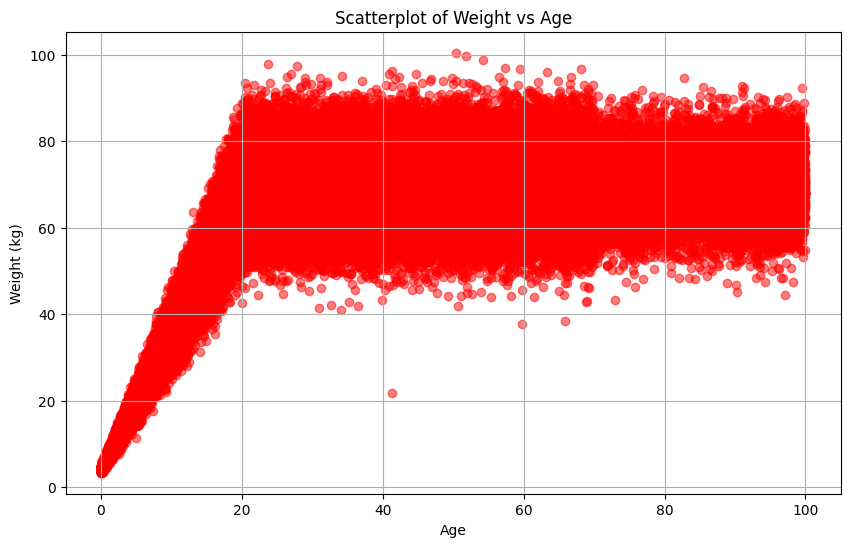

Outliers in the dataset:
                    name       age    weight
311        Edna Williams  0.092462  4.366853
643           Ken Graser  0.014489  4.028084
654      Kenneth Shevlin  0.014581  4.554047
685     Harold Davenport  0.155084  4.642049
930      Michael Calhoun  0.147751  4.356373
...                  ...       ...       ...
151720      Velvet Dever  0.419900  3.981101
151788         Ray Budde  0.566617  5.432551
151912    Andrew Jenkins  0.074917  5.155951
151922      Ida Williams  0.562629  5.223119
152069     Matthew Almen  0.288013  4.942842

[1035 rows x 3 columns]


In [9]:
# Scatter plot of weight vs age
plt.figure(figsize=(10, 6))
plt.scatter(data['age'], data['weight'], alpha=0.5, color='red')
plt.title('Scatterplot of Weight vs Age')
plt.xlabel('Age')
plt.ylabel('Weight (kg)')
plt.grid(True)
plt.show()

# Outlier detection using z-scores for weight
from scipy.stats import zscore
data['weight_zscore'] = zscore(data['weight'])

# Identify outliers (z-score greater than 3 or less than -3)
outliers = data[(data['weight_zscore'] > 3) | (data['weight_zscore'] < -3)]
print("Outliers in the dataset:")
print(outliers[['name', 'age', 'weight']])
